# Markov Chain Simulation
Simulating a Markov chain with a given transition matrix (converted from MATLAB)

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def nextstep(x, u, P):
    """
    Determine the next state based on current state x, 
    random number u, and transition matrix P
    """
    r = np.concatenate([[0], np.cumsum(P[x, :])])  # Cumulative probabilities
    for j in range(len(P)):
        if (u > r[j]) and (u <= r[j+1]):
            y = j
            return y
    return len(P) - 1  # Fallback to last state

def MCsim(n, P, startstate):
    """
    Simulate a Markov chain for n steps
    
    Parameters:
    n: Number of steps to simulate
    P: Transition matrix
    startstate: Initial state (0-indexed in Python)
    
    Returns:
    x: Array of states visited
    """
    j = startstate
    x = [j]
    
    for i in range(n):
        j = nextstep(j, np.random.rand(), P)
        x.append(j)
    
    return x

In [11]:
# Parameters
n = 79  # Number of steps to simulate
P = np.array([[1/2, 1/4, 1/4], 
              [1/4, 1/2, 1/4], 
              [1/4, 1/4, 1/2]])
startstate = 0  # Initial state (0-indexed in Python, was 1 in MATLAB)

# Run simulation
x = MCsim(n, P, startstate)

# Display results
print("Simulated Markov Chain:")
print(x)
print(f"\nTotal steps: {len(x)-1}")
print(f"States visited: {x}")

Simulated Markov Chain:
[0, 1, 2, 2, 2, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 0, 0, 2, 2, 1, 2, 2, 1, 1, 0, 0, 0, 0, 0, 0, 2, 2, 2, 0, 0, 2, 1, 0, 0, 0, 1, 1, 0, 1, 0, 2, 1, 2, 1, 1, 1, 1, 1, 0, 0, 2, 1, 0, 0, 1, 1, 2, 2, 1, 2, 0, 1, 2, 2, 0, 1, 1, 1, 1, 1, 1]

Total steps: 79
States visited: [0, 1, 2, 2, 2, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 0, 0, 2, 2, 1, 2, 2, 1, 1, 0, 0, 0, 0, 0, 0, 2, 2, 2, 0, 0, 2, 1, 0, 0, 0, 1, 1, 0, 1, 0, 2, 1, 2, 1, 1, 1, 1, 1, 0, 0, 2, 1, 0, 0, 1, 1, 2, 2, 1, 2, 0, 1, 2, 2, 0, 1, 1, 1, 1, 1, 1]


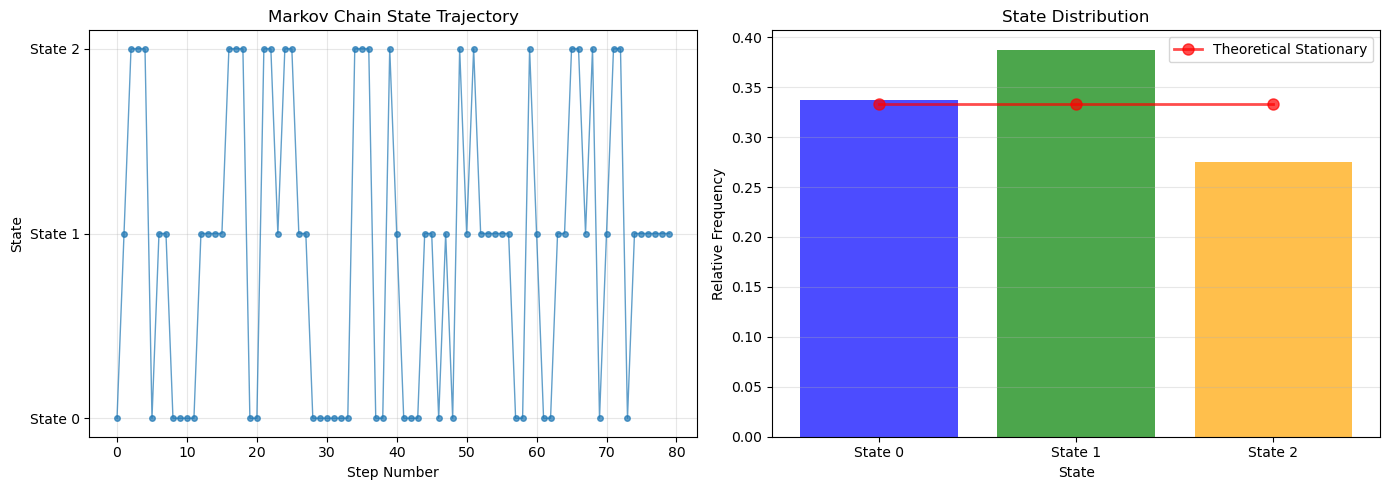


Simulation Statistics:
--------------------------------------------------
State 0:  27 visits (0.3375) | Theoretical: 0.3333
State 1:  31 visits (0.3875) | Theoretical: 0.3333
State 2:  22 visits (0.2750) | Theoretical: 0.3333
--------------------------------------------------


In [12]:
# Visualize the Markov chain path
plt.figure(figsize=(14, 5))

# Plot 1: State trajectory over time
plt.subplot(1, 2, 1)
plt.plot(x, 'o-', markersize=4, linewidth=1, alpha=0.7)
plt.xlabel('Step Number')
plt.ylabel('State')
plt.title('Markov Chain State Trajectory')
plt.yticks([0, 1, 2], ['State 0', 'State 1', 'State 2'])
plt.grid(True, alpha=0.3)

# Plot 2: State frequency distribution
plt.subplot(1, 2, 2)
unique, counts = np.unique(x, return_counts=True)
plt.bar(unique, counts / len(x), alpha=0.7, color=['blue', 'green', 'orange'])
plt.xlabel('State')
plt.ylabel('Relative Frequency')
plt.title('State Distribution')
plt.xticks([0, 1, 2], ['State 0', 'State 1', 'State 2'])
plt.grid(True, alpha=0.3, axis='y')

# Add theoretical stationary distribution
stationary = np.linalg.matrix_power(P, 100)[0, :]
plt.plot(unique, stationary[unique], 'ro-', markersize=8, linewidth=2, 
         label='Theoretical Stationary', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

# Print statistics
print("\nSimulation Statistics:")
print("-" * 50)
for state in range(3):
    count = x.count(state)
    freq = count / len(x)
    theo = stationary[state]
    print(f"State {state}: {count:3d} visits ({freq:.4f}) | Theoretical: {theo:.4f}")
print("-" * 50)

## Sierpinski Triangle using Iterated Function System (IFS)
Simulating a trajectory that draws the Sierpinski triangle using random affine transformations

In [13]:
# Parameters for Sierpinski Triangle
n = 50000  # Number of iterations

# Scaling matrix (same for all maps)
A = np.array([[1/2, 0], 
              [0, 1/2]])

# Translation vectors for the three vertices of the triangle
b1 = np.array([0, 0])
b2 = np.array([1/2, 0])
b3 = np.array([1/4, np.sqrt(3)/4])

# Probabilities for each transformation
p = np.array([1/3, 1/3, 1/3])

# Starting point
x = np.array([0, 0])

# Store trajectory
trajectory = [x.copy()]

# Simulate the IFS
for i in range(n):
    u = np.random.rand()
    
    if u < p[0]:
        x = A @ x + b1
    elif u < p[0] + p[1]:
        x = A @ x + b2
    else:
        x = A @ x + b3
    
    trajectory.append(x.copy())

# Convert trajectory to numpy array for easier plotting
trajectory = np.array(trajectory)

print(f"Generated {n} points for the Sierpinski triangle")

Generated 50000 points for the Sierpinski triangle


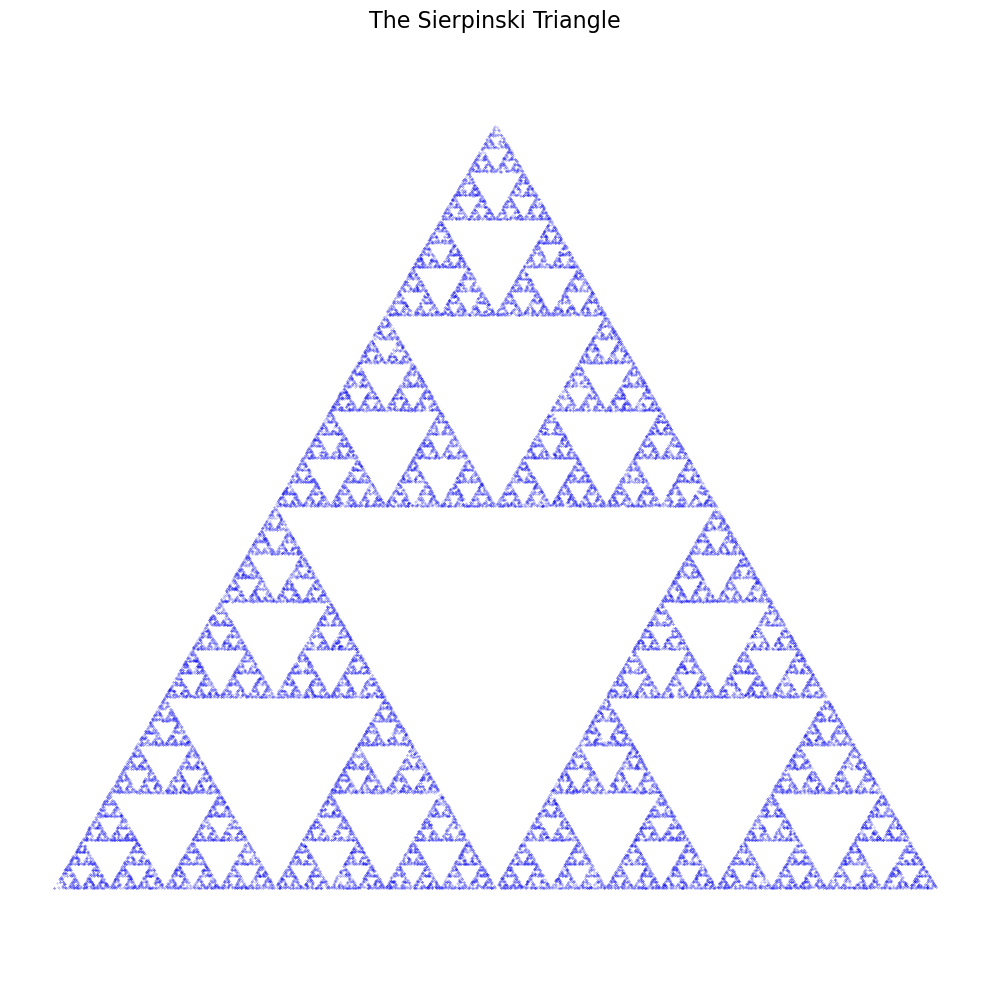

In [14]:
# Visualize the Sierpinski Triangle
plt.figure(figsize=(10, 10))
plt.plot(trajectory[:, 0], trajectory[:, 1], '.', markersize=0.5, color='blue', alpha=0.5)
plt.title('The Sierpinski Triangle', fontsize=16)
plt.axis('equal')
plt.axis('off')
plt.tight_layout()
plt.show()

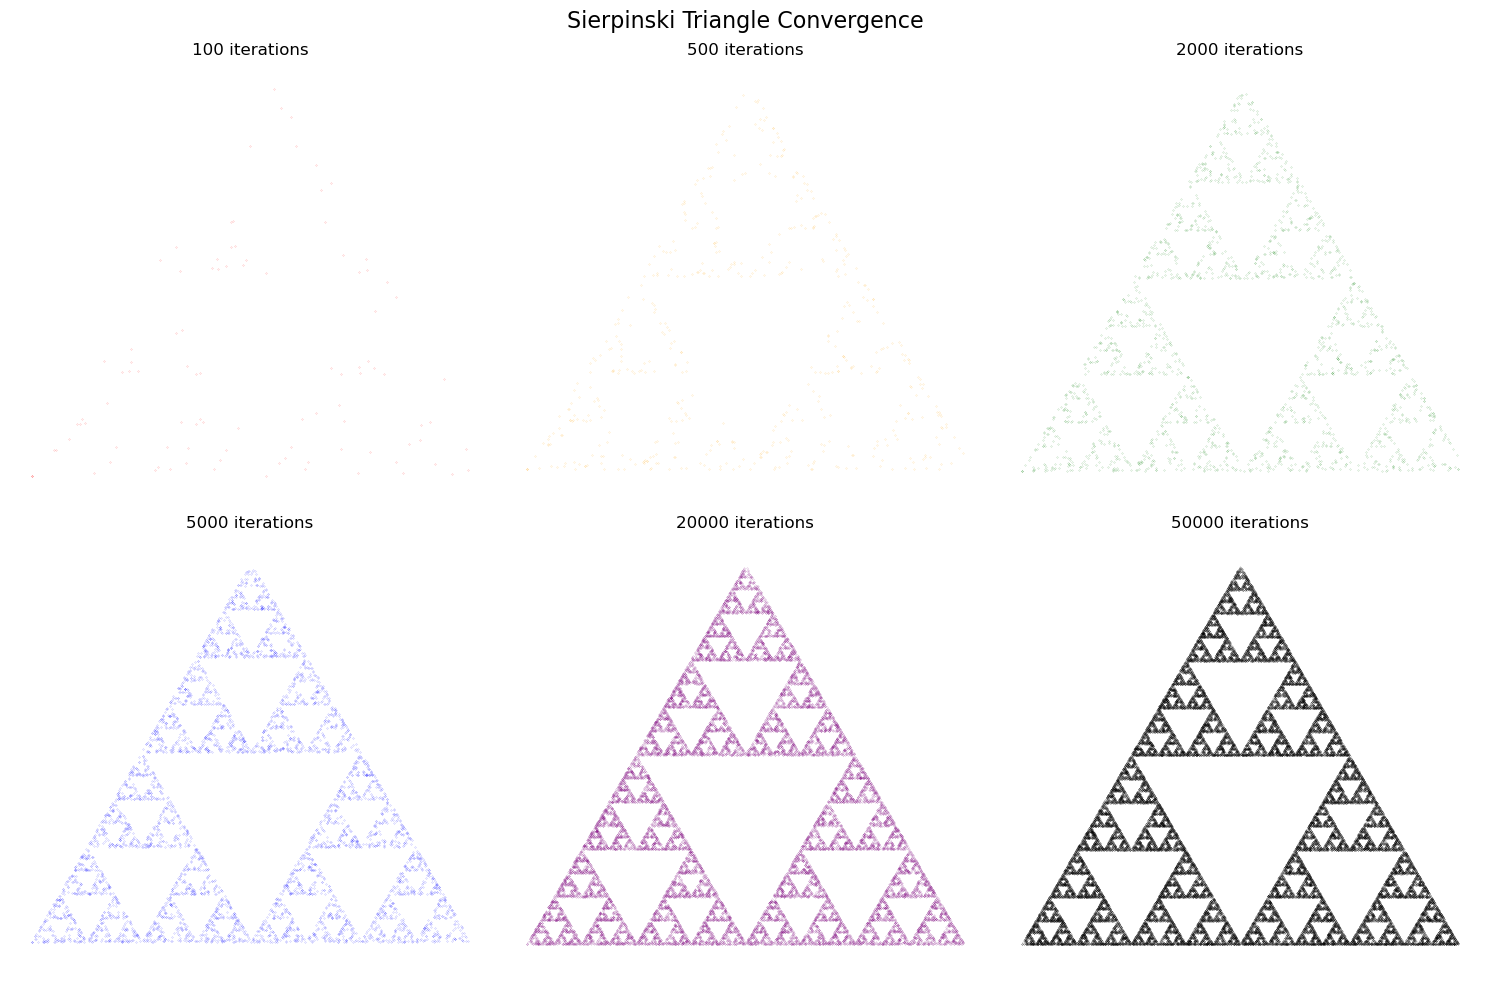

In [15]:
# Multiple visualizations of the Sierpinski Triangle
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Different numbers of iterations to show convergence
iterations_list = [100, 500, 2000, 5000, 20000, 50000]
colors = ['red', 'orange', 'green', 'blue', 'purple', 'black']

for idx, (ax, num_iter, color) in enumerate(zip(axes.flatten(), iterations_list, colors)):
    # Use the already computed trajectory or a subset
    if num_iter <= n:
        subset = trajectory[:num_iter]
    else:
        subset = trajectory
    
    ax.plot(subset[:, 0], subset[:, 1], '.', markersize=0.3, color=color, alpha=0.6)
    ax.set_title(f'{num_iter} iterations', fontsize=12)
    ax.axis('equal')
    ax.axis('off')

plt.suptitle('Sierpinski Triangle Convergence', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

## Barnsley's Fern using Iterated Function System (IFS)
Simulating a trajectory that draws Barnsley's fern using weighted random affine transformations

In [16]:
# Parameters for Barnsley's Fern
n = 50000  # Number of iterations

# Four affine transformations
A1 = np.array([[0, 0], [0, 0.16]])      # Stem
A2 = np.array([[0.85, 0.04], [-0.04, 0.85]])   # Main frond
A3 = np.array([[0.2, -0.26], [0.23, 0.22]])    # Left leaflet
A4 = np.array([[-0.15, 0.28], [0.26, 0.24]])   # Right leaflet

# Translation vectors
b1 = np.array([0, 0])
b2 = np.array([0, 1.6])
b3 = np.array([0, 1.6])
b4 = np.array([0, 0.44])

# Probabilities for each transformation
p = np.array([0.01, 0.85, 0.07, 0.07])

# Starting point
x = np.array([0.0, 0.0])

# Store trajectory
fern_trajectory = [x.copy()]

# Simulate the IFS
for i in range(n):
    u = np.random.rand()
    
    if u < p[0]:
        x = A1 @ x + b1
    elif u < p[0] + p[1]:
        x = A2 @ x + b2
    elif u < p[0] + p[1] + p[2]:
        x = A3 @ x + b3
    else:
        x = A4 @ x + b4
    
    fern_trajectory.append(x.copy())

# Convert to numpy array
fern_trajectory = np.array(fern_trajectory)

print(f"Generated {n} points for Barnsley's fern")

Generated 50000 points for Barnsley's fern


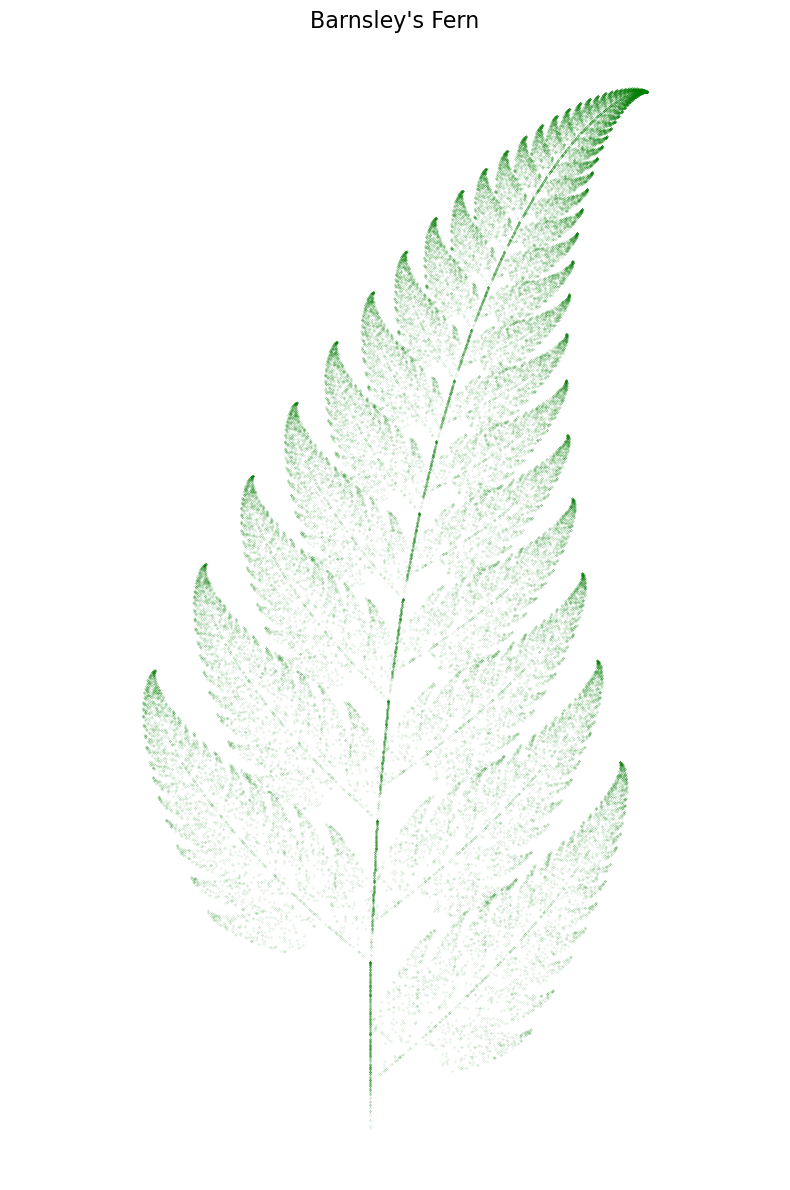

In [17]:
# Visualize Barnsley's Fern
plt.figure(figsize=(8, 12))
plt.plot(fern_trajectory[:, 0], fern_trajectory[:, 1], 'g.', markersize=0.3, alpha=0.5)
plt.title("Barnsley's Fern", fontsize=16)
plt.axis('equal')
plt.axis('off')
plt.tight_layout()
plt.show()

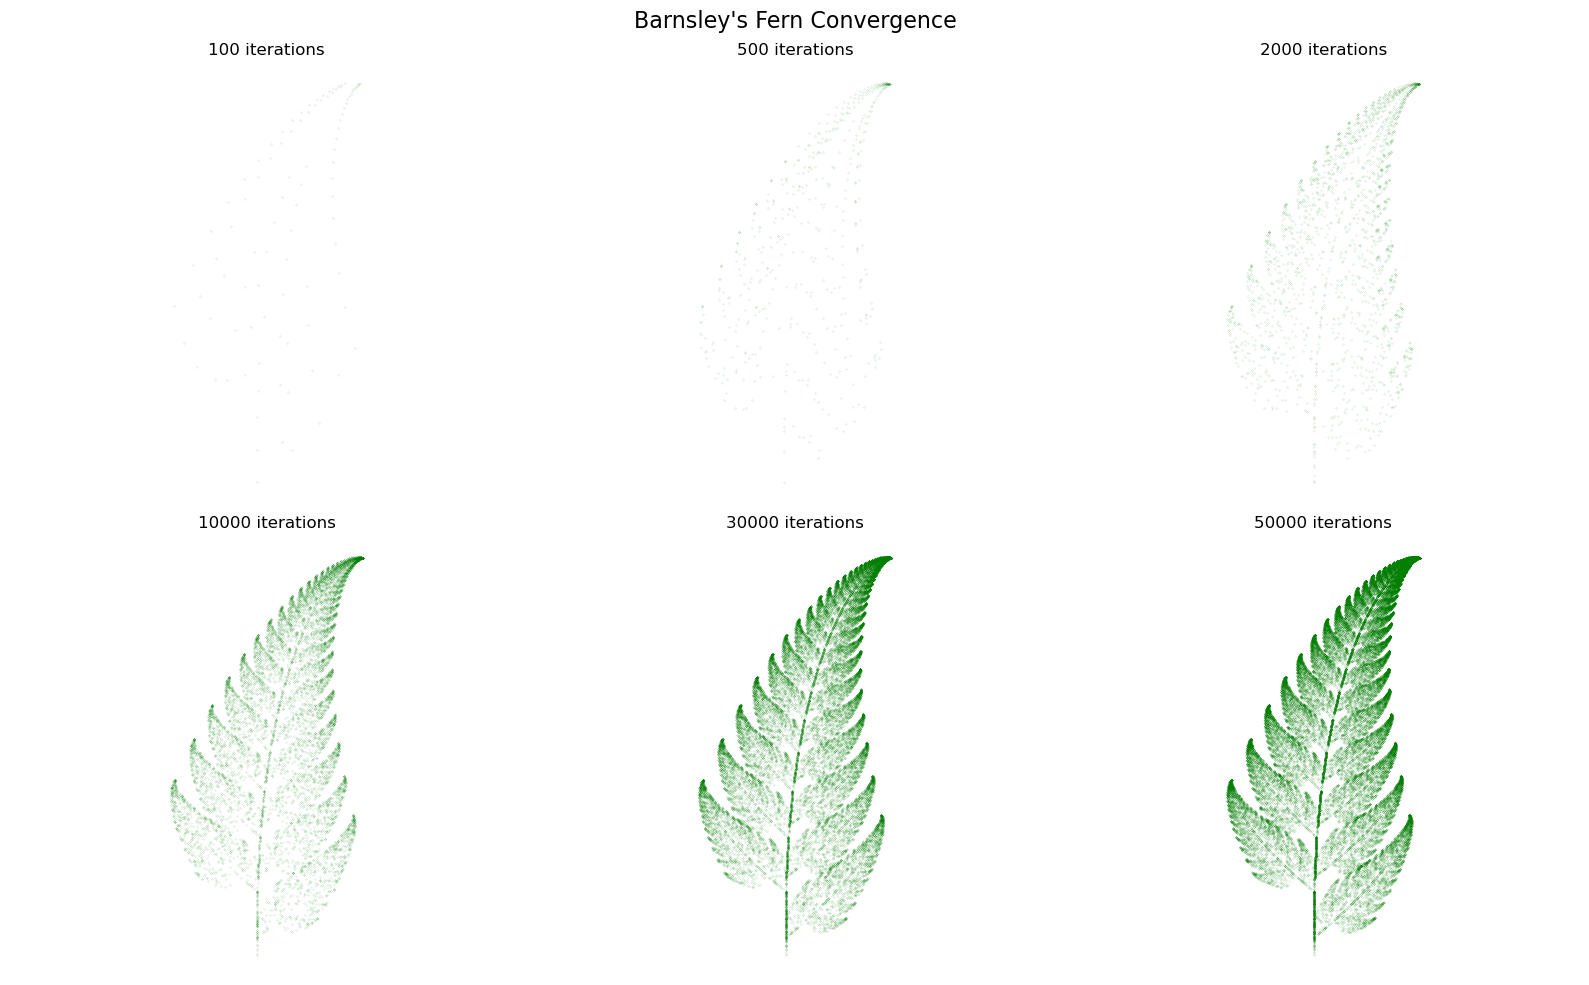

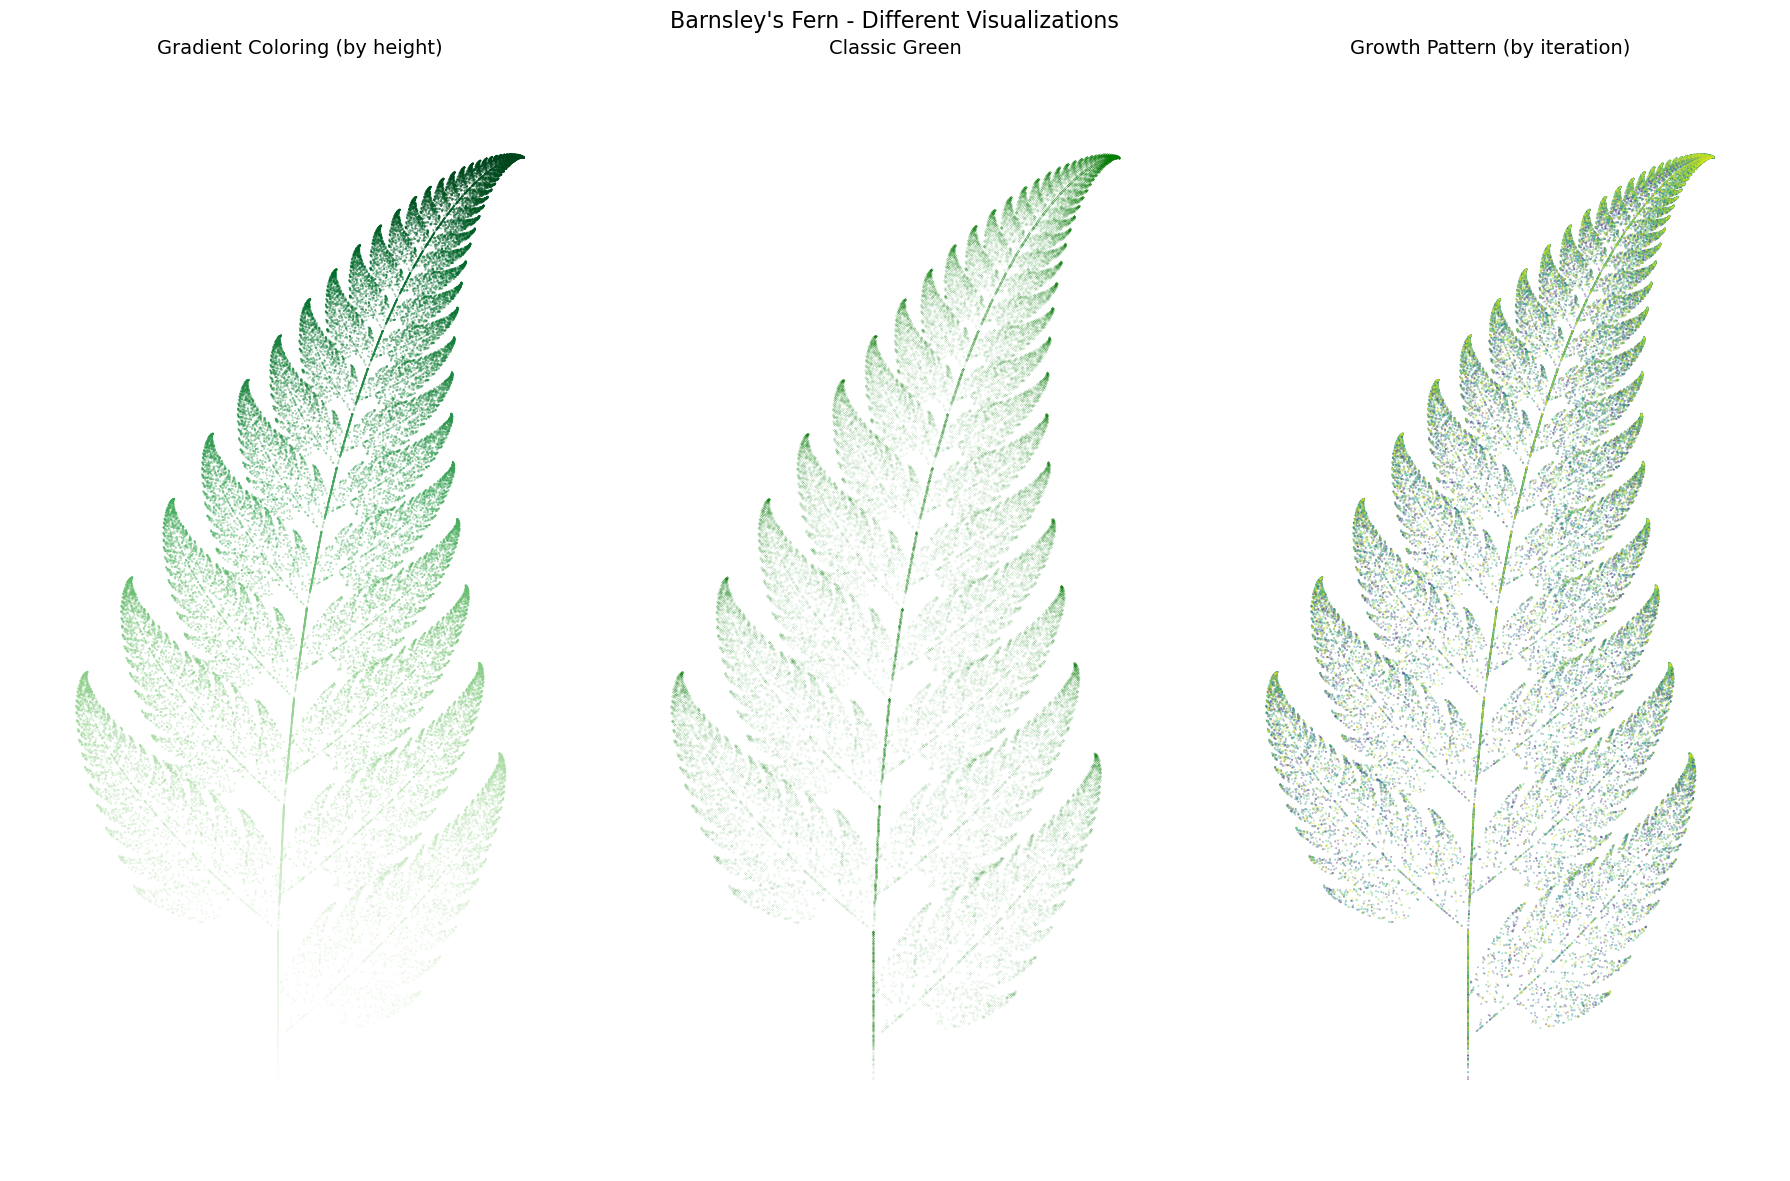


Fern Statistics:
--------------------------------------------------
Total points: 50001
X range: [-2.181, 2.656]
Y range: [0.000, 9.998]
Height/Width ratio: 2.07
--------------------------------------------------


In [18]:
# Multiple visualizations showing convergence and different color schemes
fig = plt.figure(figsize=(16, 10))

# Convergence plots
iterations_fern = [100, 500, 2000, 10000, 30000, 50000]

for idx, num_iter in enumerate(iterations_fern[:6]):
    ax = plt.subplot(2, 3, idx + 1)
    subset = fern_trajectory[:num_iter]
    ax.plot(subset[:, 0], subset[:, 1], 'g.', markersize=0.3, alpha=0.5)
    ax.set_title(f'{num_iter} iterations', fontsize=12)
    ax.axis('equal')
    ax.axis('off')

plt.suptitle("Barnsley's Fern Convergence", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

# High-quality colored version
fig, axes = plt.subplots(1, 3, figsize=(18, 12))

# Version 1: Green with gradient based on y-coordinate
im1 = axes[0].scatter(fern_trajectory[:, 0], fern_trajectory[:, 1], 
                      c=fern_trajectory[:, 1], cmap='Greens', s=0.1, alpha=0.6)
axes[0].set_title("Gradient Coloring (by height)", fontsize=14)
axes[0].axis('equal')
axes[0].axis('off')

# Version 2: Classic green
axes[1].plot(fern_trajectory[:, 0], fern_trajectory[:, 1], 'g.', markersize=0.2, alpha=0.5)
axes[1].set_title("Classic Green", fontsize=14)
axes[1].axis('equal')
axes[1].axis('off')

# Version 3: Colored by iteration order (shows growth pattern)
colors = np.arange(len(fern_trajectory))
im3 = axes[2].scatter(fern_trajectory[:, 0], fern_trajectory[:, 1], 
                      c=colors, cmap='viridis', s=0.1, alpha=0.6)
axes[2].set_title("Growth Pattern (by iteration)", fontsize=14)
axes[2].axis('equal')
axes[2].axis('off')

plt.suptitle("Barnsley's Fern - Different Visualizations", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

print("\nFern Statistics:")
print("-" * 50)
print(f"Total points: {len(fern_trajectory)}")
print(f"X range: [{fern_trajectory[:, 0].min():.3f}, {fern_trajectory[:, 0].max():.3f}]")
print(f"Y range: [{fern_trajectory[:, 1].min():.3f}, {fern_trajectory[:, 1].max():.3f}]")
print(f"Height/Width ratio: {(fern_trajectory[:, 1].max() - fern_trajectory[:, 1].min()) / (fern_trajectory[:, 0].max() - fern_trajectory[:, 0].min()):.2f}")
print("-" * 50)